In [5]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  
        for file in files[:3]:  
            print(f'{indent}  {file}')

input/
  datasets/
    killa92/
      crop-disease-image-classification-dataset/
        crop_disease_dataset/
          images/


In [6]:
base = '/kaggle/input/datasets/killa92/crop-disease-image-classification-dataset/crop_disease_dataset'
print(os.listdir(base))

['images', 'meta_deta.csv', 'class_names.json']


In [7]:
import pandas as pd
import json

In [8]:
# load metadata
meta_data=pd.read_csv(f'{base}/meta_deta.csv')
print("Shape:",meta_data.shape)
print(meta_data.head())

# load class names
with open(f'{base}/class_names.json') as f:
    class_names=json.load(f)
print("\nClasses:", class_names)

# check images folder
print("\nImages folder:", os.listdir(f'{base}/images')[:5])

Shape: (21397, 2)
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3

Classes: {'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}

Images folder: ['478554372.jpg', '2763304605.jpg', '2826122413.jpg', '231268038.jpg', '4201965605.jpg']


In [10]:
#chexh class distribution
print('Class distribution:\n')
for i,count in meta_data['label'].value_counts().sort_index().items():
    print(f'{class_names[str(i)]}:{count} images')

Class distribution:

Cassava Bacterial Blight (CBB):1087 images
Cassava Brown Streak Disease (CBSD):2189 images
Cassava Green Mottle (CGM):2386 images
Cassava Mosaic Disease (CMD):13158 images
Healthy:2577 images


In [11]:
# NOTE: meta_data.csv contains 21,397 rows but only 17,938 images
# exist in the dataset folder — filtered to existing images only
existing = set(os.listdir(f'{base}/images'))
meta_data = meta_data[meta_data['image_id'].isin(existing)].reset_index(drop=True)
print("Remaining images:", len(meta_data))

Remaining images: 17938


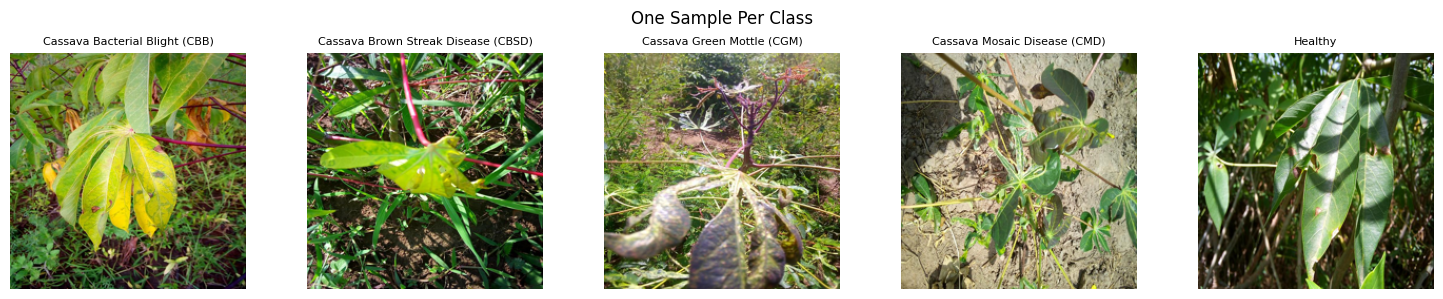

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

images_path = f'{base}/images'

# plot one image per class
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # get first available image of each class
    sample = meta_data[meta_data['label'] == i].iloc[0]
    
    # open and resize immediately to save memory
    img = Image.open(f'{images_path}/{sample["image_id"]}').resize((224, 224))
    
    axes[i].imshow(img)
    axes[i].set_title(class_names[str(i)], fontsize=8)
    axes[i].axis('off')

plt.suptitle('One Sample Per Class', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
#split data into train and  validation sets
train_df,val_df,=train_test_split(
    meta_data,
    test_size=0.2,
    stratify=meta_data['label'],
    random_state=42
)
print("Train size:",len(train_df))
print("Validation size:",len(val_df))

Train size: 14350
Validation size: 3588


In [14]:
!pip install albumentations -q

In [15]:
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# augmentation for training — adds variability to improve robustness
train_transform=A.Compose([
    A.Resize(300, 300),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# no augmentation for validation — only resize and normalize
val_transform=A.Compose([
    A.Resize(300, 300),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# custom dataset class for loading crop disease images
class CropDiseaseDataset(Dataset):
    def __init__(self, dataframe, images_path, transform=None):
        # store dataframe, path and transform
        self.dataframe = dataframe
        self.images_path = images_path
        self.transform = transform

    def __len__(self):
        # return total number of images
        return len(self.dataframe)

    def __getitem__(self, idx):
        # get image filename and label
        row=self.dataframe.iloc[idx]
        img_path=f'{self.images_path}/{row["image_id"]}'

        # read image in RGB format
        image=cv2.imread(img_path)
        image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # apply transform if given
        if self.transform:
            image=self.transform(image=image)['image']

        return image, row['label']

In [16]:
from torch.utils.data import DataLoader

# create train and validation datasets
train_dataset=CropDiseaseDataset(train_df, images_path, transform=train_transform)
val_dataset=CropDiseaseDataset(val_df, images_path, transform=val_transform)

# create dataloaders to feed images in batches
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader=DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:",len(train_loader))
print("Validation batches:",len(val_loader))

Train batches: 449
Validation batches: 113


In [17]:
!pip install efficientnet_pytorch -q

In [19]:
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

# load pretrained EfficientNet-B3
model = EfficientNet.from_pretrained('efficientnet-b3')

# replace final layer for 5 classes
model._fc = nn.Linear(model._fc.in_features, 5)

# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# move model to device
model = model.to(device)
print("Model ready!")

Loaded pretrained weights for efficientnet-b3
Device: cuda
Model ready!


In [20]:
import torch.optim as optim

# calculate class weights to handle imbalanced dataset
counts = meta_data['label'].value_counts().sort_index()
class_weights = torch.tensor(
    [1.0 / counts[i] for i in range(5)],
    dtype=torch.float
).to(device)

# cross entropy loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# adam optimizer with learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Loss function ready!")
print("Optimizer ready!")

Loss function ready!
Optimizer ready!


In [21]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # move data to device
        images = images.to(device)
        labels = labels.to(device)

        # zero gradients from previous batch
        optimizer.zero_grad()

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward pass and update weights
        loss.backward()
        optimizer.step()

        # track loss and accuracy
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [22]:
def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss=0.0
    correct=0
    total=0

    # no gradient calculation needed for validation
    with torch.no_grad():
        for images, labels in loader:
            # move data to device
            images=images.to(device)
            labels=labels.to(device)

            # forward pass only
            outputs=model(images)
            loss=criterion(outputs, labels)

            # track loss and accuracy
            running_loss+=loss.item()
            _, predicted=outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    epoch_loss=running_loss/len(loader)
    epoch_acc=correct / total
    return epoch_loss, epoch_acc

In [24]:
num_epochs = 10
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    # train and validate
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = val_epoch(model, val_loader, criterion, device)

    # save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Epoch {epoch+1}: New best model saved!")

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

Epoch 1: New best model saved!
Epoch 1/10 | Train Loss: 0.6535 | Train Acc: 0.8122 | Val Loss: 0.7180 | Val Acc: 0.8163
Epoch 2: New best model saved!
Epoch 2/10 | Train Loss: 0.5583 | Train Acc: 0.8392 | Val Loss: 0.6581 | Val Acc: 0.8372
Epoch 3: New best model saved!
Epoch 3/10 | Train Loss: 0.4777 | Train Acc: 0.8585 | Val Loss: 0.6937 | Val Acc: 0.8473
Epoch 4/10 | Train Loss: 0.4049 | Train Acc: 0.8764 | Val Loss: 0.7107 | Val Acc: 0.8294
Epoch 5/10 | Train Loss: 0.3535 | Train Acc: 0.8895 | Val Loss: 0.7577 | Val Acc: 0.8300
Epoch 6/10 | Train Loss: 0.2974 | Train Acc: 0.9040 | Val Loss: 1.3929 | Val Acc: 0.8172
Epoch 7: New best model saved!
Epoch 7/10 | Train Loss: 0.2573 | Train Acc: 0.9169 | Val Loss: 0.9014 | Val Acc: 0.8615
Epoch 8/10 | Train Loss: 0.2222 | Train Acc: 0.9266 | Val Loss: 0.9390 | Val Acc: 0.8470
Epoch 9/10 | Train Loss: 0.1985 | Train Acc: 0.9306 | Val Loss: 1.0453 | Val Acc: 0.8386
Epoch 10/10 | Train Loss: 0.1822 | Train Acc: 0.9353 | Val Loss: 1.0034 | V

In [25]:
from sklearn.metrics import classification_report
import numpy as np

# load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds=[]
all_labels=[]
# collect predictions on validation set
with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        outputs=model(images)
        _, predicted=outputs.max(1)
        all_preds.append(predicted.cpu())
        all_labels.append(labels)
# combine all batches
all_preds=torch.cat(all_preds).numpy()
all_labels=torch.cat(all_labels).numpy()

# print per-class performance
target_names=[class_names[str(i)] for i in range(5)]
print(classification_report(all_labels, all_preds, target_names=target_names))

                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.60      0.64      0.62       184
Cassava Brown Streak Disease (CBSD)       0.70      0.78      0.74       366
         Cassava Green Mottle (CGM)       0.81      0.76      0.78       399
       Cassava Mosaic Disease (CMD)       0.95      0.95      0.95      2206
                            Healthy       0.71      0.69      0.70       433

                           accuracy                           0.86      3588
                          macro avg       0.75      0.76      0.76      3588
                       weighted avg       0.86      0.86      0.86      3588



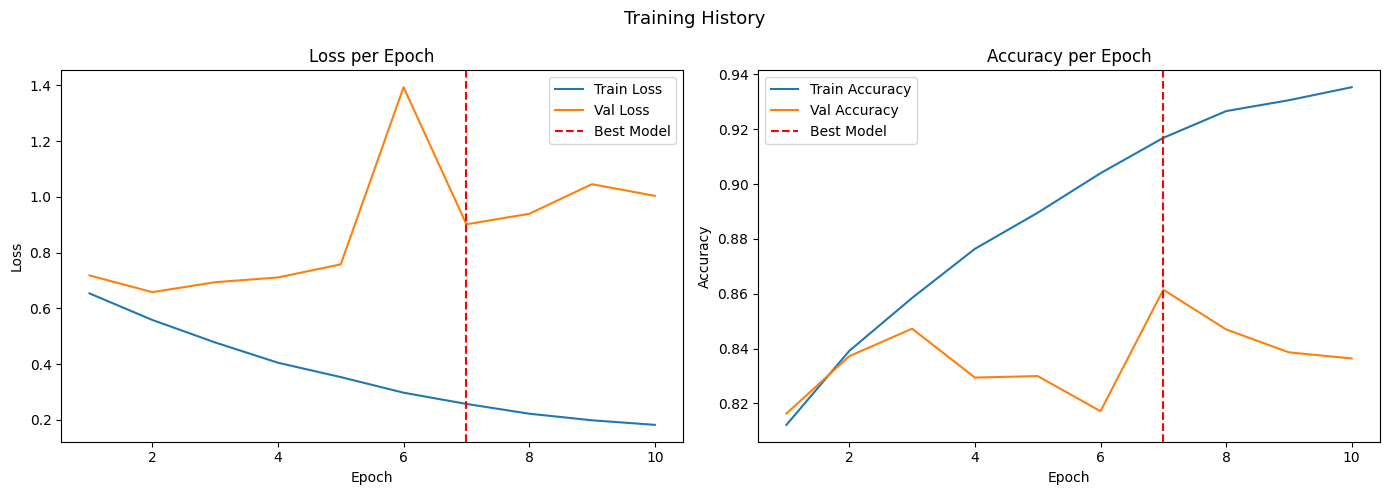

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# loss graph
axes[0].plot(epochs, history['train_loss'], label='Train Loss')
axes[0].plot(epochs, history['val_loss'], label='Val Loss')
axes[0].axvline(x=7, color='red', linestyle='--', label='Best Model')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# accuracy graph
axes[1].plot(epochs, history['train_acc'], label='Train Accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val Accuracy')
axes[1].axvline(x=7, color='red', linestyle='--', label='Best Model')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.show()

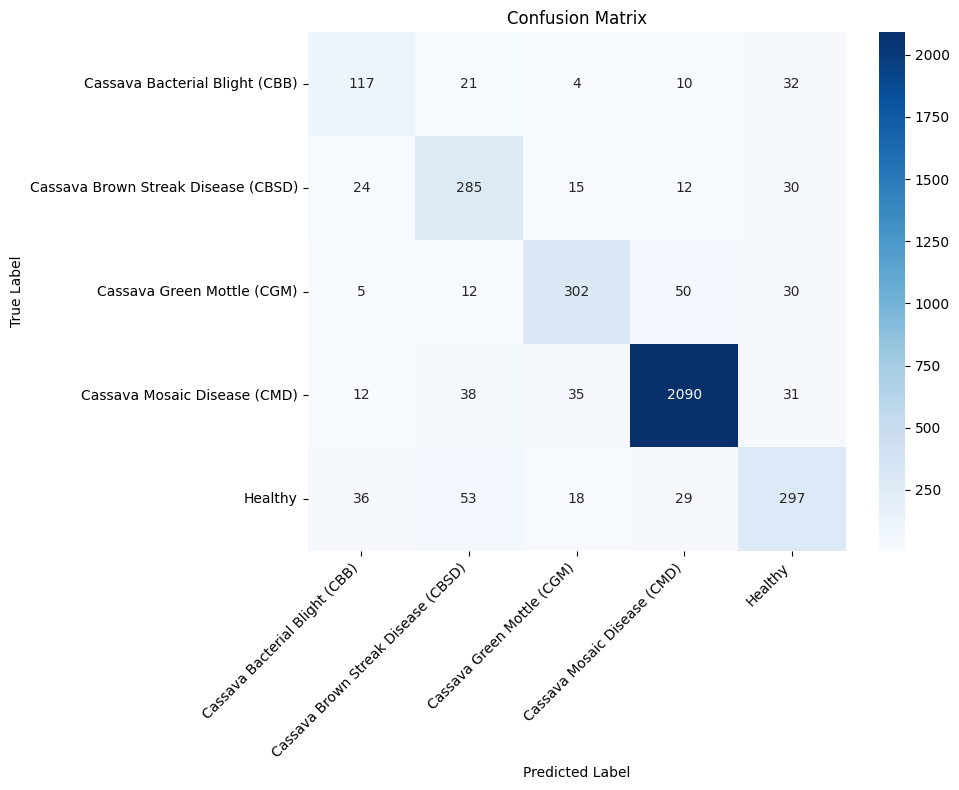

In [27]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[class_names[str(i)] for i in range(5)],
    yticklabels=[class_names[str(i)] for i in range(5)]
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()